### *ETAPA 2 Validación de las variables del Business Score*

En esta etapa se analiza el comportamiento de las variables que harán parte del modelo de segmentación. El objetivo es validar que cada una aporte información relevante para diferenciar el valor comercial de los comercios y justificar su inclusión dentro del Business Score.

#### Objetivo

Validar que las variables seleccionadas representan correctamente el valor de un comercio para el negocio antes de construir el modelo de segmentación.

#### Pregunta de negocio principal

¿Qué características debe tener un comercio para contribuir al objetivo de incrementar las comisiones generadas por la API de pagos?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
from pathlib import Path

ruta = Path("../data/raw/DataTransacciones_PruebasIngreso.xlsx")

comercios = pd.read_excel(ruta, sheet_name="comercios")
transacciones = pd.read_excel(ruta, sheet_name="transacciones")

#### Análisis de variables para el Business Score

Después del análisis exploratorio se identificaron las variables con mayor potencial para explicar el desempeño de un comercio.

En este notebook se analizará el comportamiento de cada una de ellas para validar su aporte al modelo de segmentación.

El objetivo no es construir todavía los segmentos, sino justificar por qué estas variables representan el valor del comercio desde la perspectiva del negocio.

In [6]:
transacciones_comercio = (
    transacciones
    .groupby("Id_comercio")
    .agg(
        frecuencia=("cantidad transacciones","sum"),
        promedio_mensual=("cantidad transacciones","mean"),
        meses_activos=("mes-anio transaccion","nunique")
    )
    .reset_index()
)

transacciones_comercio.head()

,Id_comercio,frecuencia,promedio_mensual,meses_activos
0,003QDVFJCJ,30,10.00,3
1,008LJH6YHN,10,2.50,4
2,00B3DGV62G,65,21.67,3
3,00ILW1BB3Y,8,2.67,3
4,01AK7UX4UU,4,2.00,2


In [7]:
# ==========================================
# Consolidación de variables del Business Score
# ==========================================

comercios_consolidado = (
    comercios
    .groupby("Id_comercio", as_index=False)
    .agg({
        "Monto ventas Acumulado": "sum",
        "Monto ventas ultimo mes": "sum"
    })
)

comercios_consolidado = comercios_consolidado.merge(
    transacciones_comercio,
    on="Id_comercio",
    how="left"
)

print(f"Comercios consolidados: {len(comercios_consolidado):,}")

display(comercios_consolidado.head())

Comercios consolidados: 3,015


,Id_comercio,Monto ventas Acumulado,Monto ventas ultimo mes,frecuencia,promedio_mensual,meses_activos
0,003QDVFJCJ,6542000,1240000,30,10.00,3
1,008LJH6YHN,4380000,1102000,10,2.50,4
2,00B3DGV62G,11892500,1297000,65,21.67,3
3,00ILW1BB3Y,372500,74500,8,2.67,3
4,01AK7UX4UU,165500,0,4,2.00,2


#### Pregunta de negocio 1

¿La *frecuencia de transacciones* es un buen indicador del valor de los comercios para el negocio?

In [8]:
# ==========================================
# Frecuencia de transacciones
# Estadísticos descriptivos
# ==========================================

transacciones_comercio["frecuencia"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count   3,015.00
mean       22.60
std        43.20
min         1.00
25%         3.00
50%        10.00
75%        23.00
90%        53.00
95%        86.00
99%       191.44
max       740.00
Name: frecuencia, dtype: float64

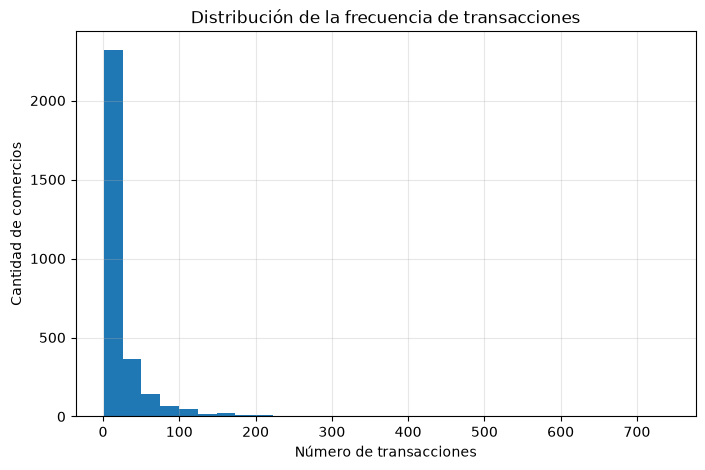

In [9]:
# ==========================================
# Distribución de la frecuencia
# ==========================================

plt.figure(figsize=(8,5))

plt.hist(
    transacciones_comercio["frecuencia"],
    bins=30
)

plt.title("Distribución de la frecuencia de transacciones")
plt.xlabel("Número de transacciones")
plt.ylabel("Cantidad de comercios")

plt.grid(alpha=0.3)

plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_23580\4085432303.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(transacciones_comercio["frecuencia"],


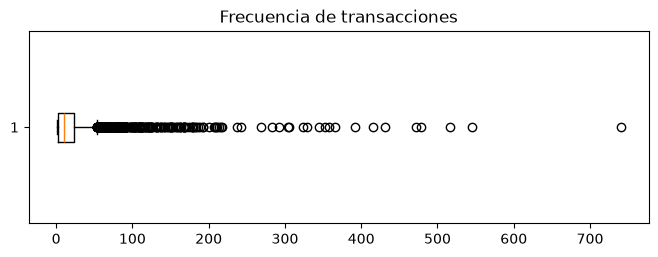

In [10]:
# ==========================================
# Identificación de valores extremos
# ==========================================

plt.figure(figsize=(8,2.5))

plt.boxplot(transacciones_comercio["frecuencia"],
            vert=False)

plt.title("Frecuencia de transacciones")

plt.show()

In [11]:
# ==========================================
# Top 10 % de comercios
# ==========================================

top10 = transacciones_comercio["frecuencia"].quantile(0.90)

top = transacciones_comercio[
    transacciones_comercio["frecuencia"] >= top10
]

participacion = (
    top["frecuencia"].sum()
    / transacciones_comercio["frecuencia"].sum()
    *100
)

print(f"Top 10% de comercios: {len(top)}")
print(f"Participación en transacciones: {participacion:.2f}%")

Top 10% de comercios: 307
Participación en transacciones: 51.64%


In [12]:
# ==========================================
# Comercios con mayor frecuencia
# ==========================================

transacciones_comercio.sort_values(
    "frecuencia",
    ascending=False
).head(10)

,Id_comercio,frecuencia,promedio_mensual,meses_activos
2861,XXT5K6PV0X,740,123.33,6
2083,OME88Q9REM,545,181.67,3
329,3L6MN1WKT0,517,86.17,6
553,63WBCXK3U8,479,159.67,3
1666,JIEJ5WGDTI,472,78.67,6
1724,K81AB3YYWE,431,107.75,4
1951,N3G1Y8W789,415,138.33,3
825,9H9ABU528P,392,130.67,3
660,7DCUZ4SAI7,366,61.00,6
1527,HYE8AWJPKY,358,119.33,3


##### Hallazgo 1

La frecuencia de transacciones presenta una distribución fuertemente asimétrica hacia la derecha.

La mayoría de los comercios realizan pocas transacciones durante el período analizado, mientras que un grupo reducido concentra una actividad considerablemente superior.

Esta diferencia evidencia que la frecuencia es una variable con alta capacidad para discriminar el desempeño entre comercios, por lo que constituye uno de los principales componentes del Business Score.

##### Hallazgo 2

La media (22,6 transacciones) es significativamente superior a la mediana (10 transacciones), lo que indica la presencia de comercios con una actividad excepcionalmente alta que incrementan el promedio general.

Por esta razón, la mediana representa de manera más adecuada el comportamiento típico de los comercios que la media.

##### Hallazgo 3

Aunque la mayoría de los comercios registra una actividad moderada, El 10 % de los comercios concentra el 51,64 % de las transacciones, evidenciando que la actividad del negocio se encuentra parcialmente concentrada en un grupo reducido de clientes. Esto justifica priorizar la frecuencia como una de las variables con mayor peso dentro del Business Score.

Este comportamiento evidencia que la generación de comisiones no se distribuye de manera uniforme entre todos los clientes, por lo que resulta conveniente diferenciar estrategias comerciales según el nivel de actividad de cada comercio.

##### Hallazgo 4

Los valores extremos observados en la frecuencia no representan errores de calidad de datos, sino comercios con un volumen transaccional significativamente superior.

Dado que estos comercios constituyen precisamente los clientes de mayor interés para el negocio, no serán eliminados ni tratados como anomalías, sino incorporados al modelo de segmentación.

#### Pregunta de negocio 2

¿Las *ventas acumuladas* representan adecuadamente el valor histórico de los comercios?

In [13]:
# ==========================================================
# Validación de la información por terminal
#
# Objetivo:
# Verificar si las ventas acumuladas corresponden a cada
# terminal o si representan el total del comercio.
# ==========================================================

duplicados = comercios[
    comercios["Id_comercio"].duplicated(keep=False)
].sort_values(["Id_comercio","Id_terminal"])

display(
    duplicados[
        [
            "Id_comercio",
            "Id_terminal",
            "Monto ventas Acumulado",
            "Monto ventas ultimo mes"
        ]
    ].head(30)
)

,Id_comercio,Id_terminal,Monto ventas Acumulado,Monto ventas ultimo mes
97,15VSQZS9OS,730,3271600,1012000
96,15VSQZS9OS,744,1862800,121800
197,266OCTDJC5,832,7210,0
198,266OCTDJC5,1871,2000,0
311,3EICTQJZ66,1138,2000,0
312,3EICTQJZ66,2775,1378000,253000
388,4AX7GUYCLI,126,4990000,0
389,4AX7GUYCLI,127,4757000,0
419,4NW1JZ9BSG,531,6626000,260000
420,4NW1JZ9BSG,532,12378750,628000


In [14]:
# ==========================================
# Consolidación de ventas por comercio
# ==========================================

ventas_comercio = (
    comercios
    .groupby("Id_comercio", as_index=False)
    .agg({
        "Monto ventas Acumulado":"sum",
        "Monto ventas ultimo mes":"sum"
    })
)

ventas_comercio.head()

,Id_comercio,Monto ventas Acumulado,Monto ventas ultimo mes
0,003QDVFJCJ,6542000,1240000
1,008LJH6YHN,4380000,1102000
2,00B3DGV62G,11892500,1297000
3,00ILW1BB3Y,372500,74500
4,01AK7UX4UU,165500,0


In [15]:
# ==========================================================
# Estadísticos descriptivos
#
# Objetivo:
# Conocer la distribución general de las ventas acumuladas de
# los comercios e identificar posibles asimetrías o valores
# extremos.
# ==========================================================

ventas_comercio["Monto ventas Acumulado"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count         3,015.00
mean      4,388,275.40
std       7,785,726.99
min               0.00
25%         325,700.00
50%       1,554,000.00
75%       4,976,200.00
90%      11,979,160.00
95%      18,511,800.00
99%      36,868,506.86
max     104,180,900.00
Name: Monto ventas Acumulado, dtype: float64

In [16]:
# ==========================================================
# Medidas de tendencia central y dispersión
#
# Objetivo:
# Comparar la media y la mediana para identificar posibles
# sesgos en la distribución de las ventas acumuladas.
# ==========================================================

print(f"Media: {ventas_comercio['Monto ventas Acumulado'].mean():,.2f}")

print(f"Mediana: {ventas_comercio['Monto ventas Acumulado'].median():,.2f}")

print(f"Desviación estándar: {ventas_comercio['Monto ventas Acumulado'].std():,.2f}")

Media: 4,388,275.40
Mediana: 1,554,000.00
Desviación estándar: 7,785,726.99


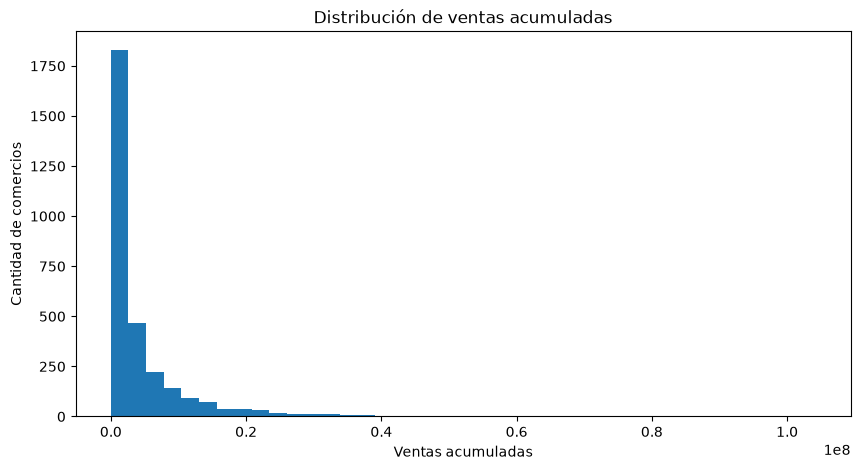

In [17]:
# ==========================================================
# Histograma de ventas acumuladas
#
# Objetivo:
# Visualizar cómo se distribuye el valor histórico de ventas
# entre los comercios.
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    ventas_comercio["Monto ventas Acumulado"],
    bins=40
)

plt.title("Distribución de ventas acumuladas")

plt.xlabel("Ventas acumuladas")

plt.ylabel("Cantidad de comercios")

plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_23580\3741120593.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


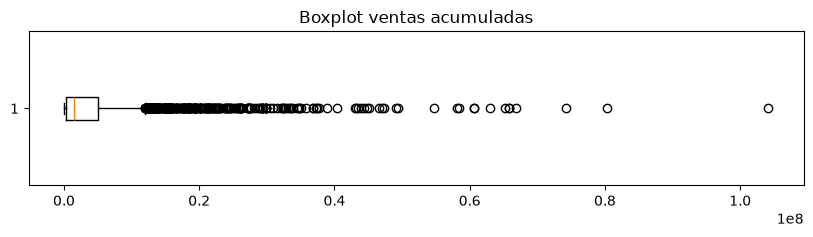

In [18]:
# ==========================================================
# Boxplot de ventas acumuladas
#
# Objetivo:
# Identificar la presencia de valores extremos y evaluar si
# corresponden a comercios con alto desempeño.
# ==========================================================

plt.figure(figsize=(10,2))

plt.boxplot(
    ventas_comercio["Monto ventas Acumulado"],
    vert=False
)

plt.title("Boxplot ventas acumuladas")

plt.show()

In [19]:
# ==========================================================
# Comercios con mayores ventas acumuladas
#
# Objetivo:
# Identificar los comercios con mayor valor histórico de ventas
# durante el período disponible.
# ==========================================================

top_ventas = (
    ventas_comercio[
        [
            "Id_comercio",
            "Monto ventas Acumulado",
            "Monto ventas ultimo mes"
        ]
    ]
    .sort_values(
        "Monto ventas Acumulado",
        ascending=False
    )
    .head(10)
)

display(top_ventas)

,Id_comercio,Monto ventas Acumulado,Monto ventas ultimo mes
2799,XFZCYU819H,104180900,8606000
1220,E73K1PXPMQ,80330200,17596000
2139,PAFLWUILLV,74277300,1362000
2960,ZBB5JOFDMW,66773400,9345000
2438,SY0QKWNVDI,65847000,4215000
660,7DCUZ4SAI7,65792600,7845000
2796,XE2MFQI79W,65246000,9112000
2931,YVIJPP1A0G,63047850,5683850
2637,VBSAT55ORN,60642400,7546000
2434,SWLG7R2XAH,60638400,2718900


##### Hallazgo 5

Las ventas acumuladas presentan una distribución fuertemente asimétrica hacia la derecha.

La mayoría de los comercios registra montos históricos relativamente bajos, mientras que un grupo reducido concentra un volumen de ventas considerablemente superior.

Esta distribución indica que el monto acumulado posee una alta capacidad para diferenciar comercios según su aporte histórico al negocio, por lo que constituye una variable relevante para el Business Score.

##### Hallazgo 6

La media ($4,39 millones) es considerablemente superior a la mediana ($1,55 millones), lo que evidencia la existencia de comercios con ventas históricas excepcionalmente altas que elevan el promedio general.

En consecuencia, la mediana representa de forma más adecuada el comportamiento típico de los comercios que la media.

##### Hallazgo 7

Los valores extremos observados en las ventas acumuladas no corresponden a errores de calidad de datos, sino a comercios con un desempeño comercial significativamente superior.

Por esta razón, dichos registros no deben eliminarse durante el proceso de segmentación, ya que representan precisamente a los clientes de mayor valor para el negocio.

##### Hallazgo 8

Durante la validación de calidad se identificó que algunos comercios poseen múltiples terminales, cada una con valores independientes de ventas acumuladas y ventas del último mes.

Por esta razón, antes del análisis fue necesario consolidar la información a nivel de comercio mediante la suma de los montos registrados por cada terminal.

Esta transformación garantiza que el Business Score evalúe el valor total generado por cada comercio y no el desempeño individual de sus terminales.

#### Pregunta de negocio 3

¿Las *ventas del último mes* permiten identificar el comportamiento reciente de los comercios?

In [20]:
# ==========================================
# 1. Estadísticos descriptivos
# ==========================================

comercios_consolidado["Monto ventas ultimo mes"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count        3,015.00
mean       669,759.92
std      1,532,529.02
min              0.00
25%              0.00
50%        110,000.00
75%        682,450.00
90%      1,848,400.00
95%      3,142,700.00
99%      6,905,160.00
max     32,650,000.00
Name: Monto ventas ultimo mes, dtype: float64

In [21]:
# ==========================================
# 2. Medidas de tendencia central y dispersión
# ==========================================

print(f"Media: {comercios_consolidado['Monto ventas ultimo mes'].mean():,.2f}")

print(f"Mediana: {comercios_consolidado['Monto ventas ultimo mes'].median():,.2f}")

print(f"Desviación estándar: {comercios_consolidado['Monto ventas ultimo mes'].std():,.2f}")

Media: 669,759.92
Mediana: 110,000.00
Desviación estándar: 1,532,529.02


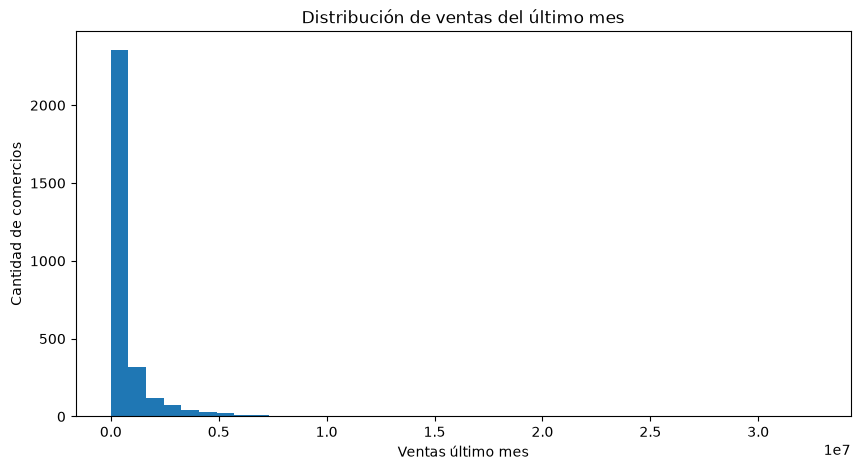

In [22]:
# ==========================================
# 3. Distribución de ventas del último mes
# ==========================================

plt.figure(figsize=(10,5))

plt.hist(
    comercios_consolidado["Monto ventas ultimo mes"],
    bins=40
)

plt.title("Distribución de ventas del último mes")

plt.xlabel("Ventas último mes")

plt.ylabel("Cantidad de comercios")

plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_23580\2631923612.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


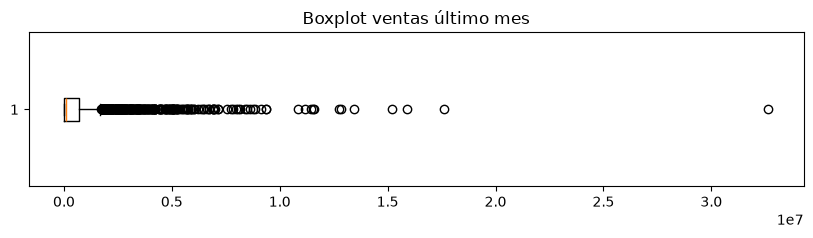

In [23]:
# ==========================================
# 4. Valores extremos
# ==========================================

plt.figure(figsize=(10,2))

plt.boxplot(
    comercios_consolidado["Monto ventas ultimo mes"],
    vert=False
)

plt.title("Boxplot ventas último mes")

plt.show()

In [24]:
# ==========================================
# 5. Participación del Top 10 %
# ==========================================

top_10 = int(len(comercios_consolidado) * 0.10)

top = (
    comercios_consolidado
    .sort_values(
        "Monto ventas ultimo mes",
        ascending=False
    )
    .head(top_10)
)

participacion = (
    top["Monto ventas ultimo mes"].sum()
    /
    comercios_consolidado["Monto ventas ultimo mes"].sum()
) * 100

print(f"Top 10% de comercios: {top_10}")

print(f"Participación en ventas del último mes: {participacion:.2f}%")

Top 10% de comercios: 301
Participación en ventas del último mes: 60.91%


In [25]:
# ==========================================
# 6. Comercios con mayores ventas recientes
# ==========================================

(
    comercios_consolidado[
        [
            "Id_comercio",
            "Monto ventas ultimo mes",
            "Monto ventas Acumulado"
        ]
    ]
    .sort_values(
        "Monto ventas ultimo mes",
        ascending=False
    )
    .head(10)
)

,Id_comercio,Monto ventas ultimo mes,Monto ventas Acumulado
2760,WUYO9PGW2L,32650000,58092000
1220,E73K1PXPMQ,17596000,80330200
1119,D1BTL1JSWO,15892000,37409000
382,4ABJ0CHA7B,15200000,43522000
1617,IZ1KMQTGJ0,13430000,45098000
1991,NHON1OIGF4,12860000,46572524
2461,T8XKTLFTV2,12725400,43183250
370,43JRU0X9KJ,11583000,21224000
805,972OEJ85OJ,11555000,22156500
974,BFKDFJQRCL,11450000,58483000


##### Hallazgo 1

Las ventas del último mes presentan una distribución fuertemente asimétrica hacia la derecha.

La mayoría de los comercios registró ventas recientes bajas o incluso nulas, mientras que un grupo reducido concentra un volumen considerablemente superior.

Este comportamiento indica que la actividad reciente no se distribuye de manera uniforme entre los comercios, por lo que esta variable posee una alta capacidad para diferenciar niveles de desempeño actuales.

##### Hallazgo 2

La media ($669.760) es considerablemente superior a la mediana ($110.000), lo que evidencia que un grupo reducido de comercios con ventas recientes muy altas incrementa el promedio general.

En consecuencia, la mediana representa de forma más adecuada el comportamiento típico de los comercios que la media.

##### Hallazgo 3

El 10 % de los comercios concentra el 60,91 % de las ventas del último mes, lo que evidencia una concentración aún mayor que la observada en la frecuencia de transacciones.

Este resultado sugiere que una parte importante de los ingresos recientes proviene de un grupo reducido de comercios con alto nivel de actividad.

Por esta razón, las ventas recientes constituyen una variable clave para identificar los clientes con mayor aporte económico en el período más actual.

##### Hallazgo 4

Los valores extremos observados corresponden a comercios con un volumen de ventas reciente significativamente superior al resto de la población y no representan errores en la información.

Estos comercios aportan información relevante para la segmentación, por lo que serán conservados dentro del modelo sin aplicar tratamientos para eliminar outliers.

##### Hallazgo 5

A diferencia de las ventas acumuladas, las ventas del último mes reflejan el comportamiento más reciente del comercio.

Esto permite identificar clientes que actualmente presentan un alto nivel de actividad, incluso cuando históricamente no han acumulado las mayores ventas.

Por esta razón, esta variable complementa la información histórica y aporta una dimensión temporal indispensable para la construcción del Business Score.

In [26]:
from pathlib import Path

# ==========================================
# Exportar dataset para la etapa de segmentación
# ==========================================

Path("../data/processed").mkdir(
    parents=True,
    exist_ok=True
)

comercios_consolidado.to_excel(
    "../data/processed/comercios_business_score.xlsx",
    index=False
)

print("Archivo exportado correctamente.")

Archivo exportado correctamente.
